- 06_store_member.csv 파일을, df_member로, 06_store_product.csv를 df_product로 선언하여 아래의 문제를 해결해보세요.

1. df_product데이터의 구조와 타입을 확인


In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import scipy.stats as stats

mpl.rc('font', family='Malgun Gothic')

In [2]:
df_product = pd.read_csv('06_store_product.csv')
df_member = pd.read_csv('06_store_member.csv')

In [3]:
df_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735783 entries, 0 to 735782
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   공급일자      735783 non-null  int64  
 1   물품코드      735783 non-null  int64  
 2   물품대분류     735783 non-null  object 
 3   물품중분류     735783 non-null  object 
 4   물품소분류     735783 non-null  object 
 5   물품명       735783 non-null  object 
 6   구매수량      735783 non-null  float64
 7   구매금액      735783 non-null  int64  
 8   구매매장      735783 non-null  object 
 9   반품_원거래일자  10337 non-null   float64
 10  회원번호      735761 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 61.7+ MB


2. df_product데이터의'물품대분류' 중 가장 많이 판매되는(수량)3가지 항목을 확인

In [4]:
df_product['물품대분류'].value_counts().head(3)

물품대분류
채소     193170
축산물    134486
간식     111411
Name: count, dtype: int64

3. 앞서 확인한 3가지 항목을 추출하여, df_product_top이라는 변수로 선언하고,
df_product_top에서 '구매매장'별 '구매금액'의 합과 평균을 계산

In [5]:
df_product_top = df_product[df_product['물품대분류'].isin(['채소', '축산물', '간식'])]
df_product_top.pivot_table(index='구매매장', values='구매금액', aggfunc=['sum', 'mean'])

,sum,mean
,구매금액,구매금액
구매매장,,
매장1,363985400,4770.638426
매장2,461745602,4908.271082
매장3,916748142,4949.910326
매장4,419048570,5019.146844


4. '공급일자'데이터를 날짜형식으로 변환하여, '연도' / '월' / '요일' 항목을 새로운 파생변수
로 생성 ( pd.to_datetime( ~ , format="%Y%m%d") )

In [12]:
df_product['Datetime_dt']= pd.to_datetime(df_product['공급일자'], format="%Y%m%d")
df_product['연도'] =df_product['Datetime_dt'].dt.year
df_product['월'] =df_product['Datetime_dt'].dt.month
df_product['요일'] =df_product['Datetime_dt'].dt.day_name()
df_product

,공급일자,물품코드,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,반품_원거래일자,회원번호,Datetime_dt,연도,월,요일
0,20170201,50142001,채소,잎/줄기채소,시금치,시금치(300g),1.0,2000,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday
1,20170201,60302012,축산물,육가공,돈가스/분쇄가공,튀김옷돈가스(400g),1.0,6300,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday
2,20170201,80301002,간식,밀가공,라면,감자라면(110g:1봉),2.0,2600,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday
3,20170201,80301010,간식,밀가공,라면,사리면(100g),1.0,900,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday
4,20170201,80305003,간식,밀가공,만두,고기만두(500g),1.0,5400,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735778,20170630,100201003,반찬,두부/유부,두부,두부(1모:420g),1.0,2200,매장3,NaN,2637.0,2017-06-30,2017,6,Friday
735779,20170630,100306006,반찬,즉석조리,간편요리,현미쌀가스(320g),1.0,5830,매장3,NaN,2637.0,2017-06-30,2017,6,Friday
735780,20170630,130214027,생활용품,생활용품,기타생활용품,모기기피제(로즈마리향),1.0,8470,매장3,NaN,2637.0,2017-06-30,2017,6,Friday
735781,20170630,130501098,생활용품,화장품,기초화장품,수피아 알로에베라잎즙 수딩젤,1.0,7370,매장3,NaN,2637.0,2017-06-30,2017,6,Friday


5. '월'에 따른'물품대분류'별 '구매금액'의 합을 게산하여 result8.xlsx저장

In [53]:
df_product.pivot_table(index=['월', '물품대분류'], values='구매금액', aggfunc='sum').to_excel('result8.xlsx')

6. '요일'에서 '주말'과'주중'을 구분하여,'주중과 주말의 구매금의 평균의 차이가 있는지 가설검정을 수행

In [19]:
def Distinguish_weekday(x) :
    if x == 'Monday' :
        return '주중'
    elif x == 'Tuesday' :
        return '주중'
    elif x == 'Wednesday' :
        return '주중'
    elif x == 'Thursday' :
        return '주중'
    elif x == 'Friday' :
        return '주중'
    else :
        return '주말'

df_product['주중주말구분'] = df_product['요일'].apply(Distinguish_weekday)

,공급일자,물품코드,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,반품_원거래일자,회원번호,Datetime_dt,연도,월,요일,주중주말구분
0,20170201,50142001,채소,잎/줄기채소,시금치,시금치(300g),1.0,2000,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday,주중
1,20170201,60302012,축산물,육가공,돈가스/분쇄가공,튀김옷돈가스(400g),1.0,6300,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday,주중
2,20170201,80301002,간식,밀가공,라면,감자라면(110g:1봉),2.0,2600,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday,주중
3,20170201,80301010,간식,밀가공,라면,사리면(100g),1.0,900,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday,주중
4,20170201,80305003,간식,밀가공,만두,고기만두(500g),1.0,5400,매장3,NaN,2101.0,2017-02-01,2017,2,Wednesday,주중
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735778,20170630,100201003,반찬,두부/유부,두부,두부(1모:420g),1.0,2200,매장3,NaN,2637.0,2017-06-30,2017,6,Friday,주중
735779,20170630,100306006,반찬,즉석조리,간편요리,현미쌀가스(320g),1.0,5830,매장3,NaN,2637.0,2017-06-30,2017,6,Friday,주중
735780,20170630,130214027,생활용품,생활용품,기타생활용품,모기기피제(로즈마리향),1.0,8470,매장3,NaN,2637.0,2017-06-30,2017,6,Friday,주중
735781,20170630,130501098,생활용품,화장품,기초화장품,수피아 알로에베라잎즙 수딩젤,1.0,7370,매장3,NaN,2637.0,2017-06-30,2017,6,Friday,주중


In [20]:
cond1 = (df_product['주중주말구분'] == '주중')
df_week = df_product.loc[cond1]

cond2 = (df_product['주중주말구분']== '주말')
df_weekend = df_product.loc[cond2]

In [21]:
# 귀무가설 : 주중과 주말의 '구매금액' 평균의 차이가 없다.
# 대립가설 : 주중과 주말의 '구매금액' 평균의 차이가 있다.
stats.ranksums(df_week['구매금액'], df_weekend['구매금액'])
# P-value < 0.05 / 대립가설 참 / 주중과 주말의 '구매금액' 평균의 차이가 있다. 

RanksumsResult(statistic=-3.606431695849114, pvalue=0.0003104365247243715)

7. df_product데이터에서 '회원번호' 별 '구매금액'과 '구매수량'의 합을 계산하여,
df_member 데이터에 병합해, df1 변수로 선언하시오.

In [24]:
p1 = df_product.pivot_table(index='회원번호', values=['구매금액', '구매수량'], aggfunc='sum').reset_index()

In [25]:
p2 = p1.rename(columns={'구매금액':'총구매금액', '구매수량':'총구매수량'})
df_product['Label'] = 1
p3 = df_product.pivot_table(index=['회원번호','공급일자'], 
                       values='Label', aggfunc='min').reset_index()
p4 = p3.pivot_table(index='회원번호', values='Label',aggfunc='sum').reset_index()
p5 = p4.rename(columns={'Label':'방문횟수'})

m1 = pd.merge(df_member, p2, on='회원번호', how='inner')
df1 = pd.merge(m1, p5, on='회원번호', how='inner')
df1

,회원번호,회원상태,성별,결혼유무,주소,생년,연령,총구매금액,총구매수량,방문횟수
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51,1991230,382.0,86
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71,2095860,472.5,79
2,2103,정상회원,여,기혼,경기 용인시 수지구 동천동,1972,46,8273550,1675.4,126
3,2104,정상회원,여,NaN,경기 용인시 수지구 성복동,1969,49,6289495,1401.8,125
4,2105,정상회원,여,기혼,경기 용인시 수지구 동천동,1948,70,3067930,602.0,57
...,...,...,...,...,...,...,...,...,...,...
4280,6492,정상회원,여,미혼,경기 성남시 분당구 판교동,1963,55,51550,10.0,1
4281,6493,정상회원,여,기혼,서울 관악구 행운동 1681,1982,36,22500,3.0,1
4282,6494,정상회원,남,기혼,경기 성남시 분당구 백현동,1975,43,18500,3.0,1
4283,6495,정상회원,여,기혼,서울 용산구 한남동 737-,1961,57,5300,1.0,1


8. df1 데이터에서 '연령'데이터를 이용해 '연령대_new'라는 항목 파생변수로 생성 (if문을 쓰
지 않고 생성)

In [26]:
def func1(x):
    return str(x)[0] + '0대'

df1['연령대_new']=df1['연령'].apply(func1)   
df1

,회원번호,회원상태,성별,결혼유무,주소,생년,연령,총구매금액,총구매수량,방문횟수,연령대_new
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51,1991230,382.0,86,50대
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71,2095860,472.5,79,70대
2,2103,정상회원,여,기혼,경기 용인시 수지구 동천동,1972,46,8273550,1675.4,126,40대
3,2104,정상회원,여,NaN,경기 용인시 수지구 성복동,1969,49,6289495,1401.8,125,40대
4,2105,정상회원,여,기혼,경기 용인시 수지구 동천동,1948,70,3067930,602.0,57,70대
...,...,...,...,...,...,...,...,...,...,...,...
4280,6492,정상회원,여,미혼,경기 성남시 분당구 판교동,1963,55,51550,10.0,1,50대
4281,6493,정상회원,여,기혼,서울 관악구 행운동 1681,1982,36,22500,3.0,1,30대
4282,6494,정상회원,남,기혼,경기 성남시 분당구 백현동,1975,43,18500,3.0,1,40대
4283,6495,정상회원,여,기혼,서울 용산구 한남동 737-,1961,57,5300,1.0,1,50대


9. df1 데이터에서 '결혼유무'에서 '기혼'에 해당하는 고객들 중 '방문횟수'가 높은 상위 30명
의 고객명단을 확인 

In [27]:
c1= (df1['결혼유무'] == '기혼')
df1.loc[c1].sort_values(by='방문횟수', ascending=False).head(30)

,회원번호,회원상태,성별,결혼유무,주소,생년,연령,총구매금액,총구매수량,방문횟수,연령대_new
39,2141,정상회원,여,기혼,경기 용인시 수지구 풍덕천2,1968,50,15302800,2896.70,173,50대
3645,5856,탈퇴,여,기혼,경기 용인시 수지구 신봉동,1972,46,21217470,4006.96,172,40대
2441,4649,탈퇴,여,기혼,경기 용인시 수지구 풍덕천2,1972,46,16471290,3447.20,171,40대
2857,5068,탈퇴,여,기혼,경기 용인시 수지구 동천동,1971,47,21285710,4180.50,170,40대
1928,4135,탈퇴,여,기혼,경기 용인시 수지구 신봉동,1969,49,18381620,3219.43,170,40대
156,2277,정상회원,여,기혼,경기 용인시 수지구 풍덕천2,1971,47,21950630,4425.70,170,40대
142,2260,정상회원,여,기혼,경기 용인시 수지구 풍덕천동,1977,41,18681595,3870.15,169,40대
166,2288,정상회원,여,기혼,경기 용인시 수지구 풍덕천동,1968,50,17170370,2921.50,166,50대
103,2214,정상회원,여,기혼,경기 용인시 수지구 풍덕천2,1976,42,14895300,2986.40,162,40대
372,2521,정상회원,여,기혼,경기 용인시 수지구 신봉동,1974,44,13609730,2985.55,161,40대


10. df1 데이터에서, '구매금액'의 합이 가장 높은 2개의 '연령대_new'를 확인하여, 두 연령대
간의 '구매금액'의 평균의 차이가 있는지 가설검정을 수행


In [28]:
df1.pivot_table(index='연령대_new', values='총구매금액', aggfunc='sum')
# 40, 50대의 총구매금액이 가장 높음! 
c2 = (df1['연령대_new'] == '40대')
df1_40 = df1.loc[c2]
c3 = (df1['연령대_new'] == '50대')
df1_50 = df1.loc[c3]
# 귀무가설 : 두 집단의 '총구매금액' 평균의 차이가 없다.
# 대립가설 : 두 집단의 '총구매금액' 평균의 차이가 있다.
stats.ranksums(df1_40['총구매금액'], df1_50['총구매금액'])
# # P-value > 0.05 / 귀무가설 참 / 두 집단의 '최종결제금액' 평균의 차이는 없다

RanksumsResult(statistic=-1.3865085006767923, pvalue=0.1655916863903576)

11. df1 데이터에서 '성별'에 따른 '총구매금액'의 평균을 시각화


<Axes: xlabel='성별', ylabel='합계'>

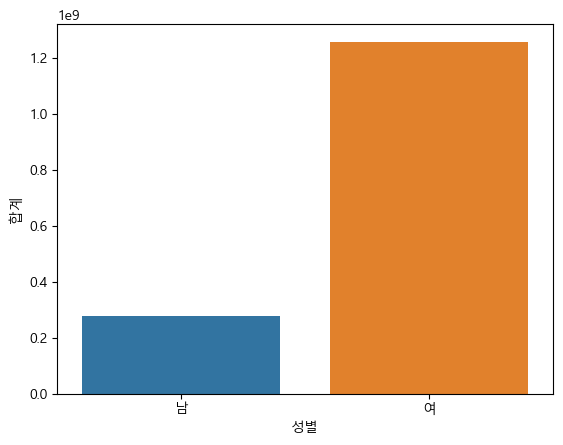

In [30]:
df1['합계'] = df1['총구매수량'] * df1['총구매금액']
p6 = df1.pivot_table(index='성별', values='합계', aggfunc='mean').reset_index()
sns.barplot(data=p6, x='성별', y='합계')

12. '1회방문구매평균'을 바탕으로 고객등급을 분류하고자 한다. 10만원 이상 고객은 A / 5만
원 이상은 B / 2만원 이상 C / 나머지는 D 등급으로 분류하여, '고객등급'이라는 새로운 항목
을 생성


In [31]:
df1['1회방문구매평균'] = df1['총구매금액'] / df1['방문횟수']
def func2(x):
    if x >= 100000 :
        return 'A'
    elif x >= 50000 :
        return 'B'
    elif x >= 20000 :
        return 'C'
    else :
        return 'D'
    
df1['고객등급'] = df1['1회방문구매평균'].apply(func2)
df1

,회원번호,회원상태,성별,결혼유무,주소,생년,연령,총구매금액,총구매수량,방문횟수,연령대_new,합계,1회방문구매평균,고객등급
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51,1991230,382.0,86,50대,7.606499e+08,23153.837209,C
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71,2095860,472.5,79,70대,9.902938e+08,26529.873418,C
2,2103,정상회원,여,기혼,경기 용인시 수지구 동천동,1972,46,8273550,1675.4,126,40대,1.386151e+10,65663.095238,B
3,2104,정상회원,여,NaN,경기 용인시 수지구 성복동,1969,49,6289495,1401.8,125,40대,8.816614e+09,50315.960000,B
4,2105,정상회원,여,기혼,경기 용인시 수지구 동천동,1948,70,3067930,602.0,57,70대,1.846894e+09,53823.333333,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4280,6492,정상회원,여,미혼,경기 성남시 분당구 판교동,1963,55,51550,10.0,1,50대,5.155000e+05,51550.000000,B
4281,6493,정상회원,여,기혼,서울 관악구 행운동 1681,1982,36,22500,3.0,1,30대,6.750000e+04,22500.000000,C
4282,6494,정상회원,남,기혼,경기 성남시 분당구 백현동,1975,43,18500,3.0,1,40대,5.550000e+04,18500.000000,D
4283,6495,정상회원,여,기혼,서울 용산구 한남동 737-,1961,57,5300,1.0,1,50대,5.300000e+03,5300.000000,D


13. '고객등급'을 입력했을 때, 해당 고객등급에서 '성별'에 따른 '총구매금액' 기술통계량을
계산하여 'result9_등급명.xlsx'저장하는 프로그램을 구성

In [45]:
def make_df_class (x) : 
    
    df_cond_man = df1[(df1['고객등급'] == x ) & (df1['성별'] == '남')]
    df_cond_woman = df1[(df1['고객등급'] == x ) & (df1['성별'] == '여')]
    
    df2 = df_cond_man.describe()['합계'].reset_index()
    df2.rename(columns={'합계' : '여자총구매금액'}, inplace=True)
    df2['남자총구매금액'] = df_cond_man.describe()['합계'].values
    return df2

In [52]:
make_df_class('C').to_excel('result9_등급명.xlsx')